# Notebook 07 - Explainability and Interventions

Two explainability frameworks on the deployed High-Risk classifier, SHAP for the
global and exact-per-student view and LIME for a local cross-check, then the
intervention engine that turns a student's SHAP attribution into a ranked action
plan.

Classifier that actually won in performance and suitability to this project is logistic
regression, so I use LinearExplainer, which is exact for linear models.


Load the saved binary classifier, the feature matrix, and the raw DS1 rows
(needed for the human-readable current values in the interventions). The
explainer is fit on the training background only.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "ml" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml import config
from ml.explainability import RiskExplainer, get_interventions
from ml.preprocessing import prepare_primary_data, derive_procrastination_level
from data.data_loader import load_dataset

sns.set_theme(style="whitegrid")

data = prepare_primary_data(save=False)
feature_names = list(data["X_train"].columns)
classifier = joblib.load(config.CLASSIFIER_BINARY_PATH)

explainer = RiskExplainer(classifier, feature_names).fit(data["X_train"])

raw = load_dataset("behavioral_analytics")
raw["procrastination_level"] = derive_procrastination_level(raw)
len(feature_names)

62

## Global picture

Beeswarm and bar summaries over the test set. The beeswarm shows both the
magnitude and the direction of each feature's effect; the bar collapses that to
mean absolute impact.

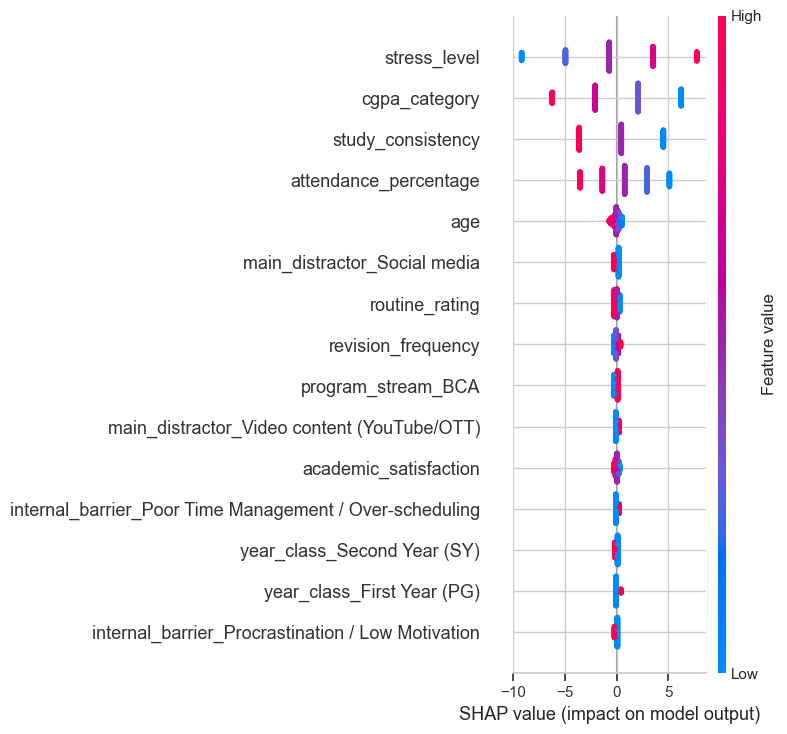

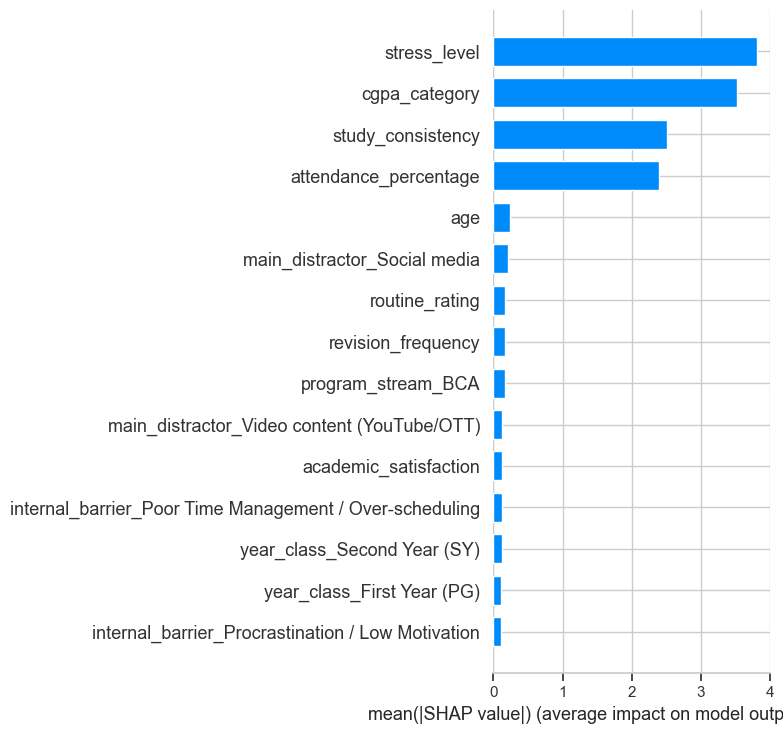

stress_level                    3.813
cgpa_category                   3.520
study_consistency               2.511
attendance_percentage           2.393
age                             0.238
main_distractor_Social media    0.213
routine_rating                  0.165
revision_frequency              0.163
dtype: float64

In [2]:
explainer.plot_beeswarm(data["X_test"], config.PLOTS_DIR / "shap_beeswarm.png")
plt.show()
explainer.plot_bar(data["X_test"], config.PLOTS_DIR / "shap_feature_importance.png")
plt.show()

explainer.mean_abs_shap(data["X_test"]).head(8).round(3)

Stress, CGPA band, study consistency and attendance dominate. Two of those
(CGPA and attendance) are closer to outcomes than to things a student changes
this week, which is exactly why the intervention engine later filters down to
the behaviours that are actually addressable. It's also a useful contrast with
the earlier assumption that raw study hours would be the top driver; consistency
and stress matter more here.

## Interaction and dependence

How procrastination's effect varies, coloured by career-goal clarity, and the
same for study hours. Axes are on the model's standardised feature scale.

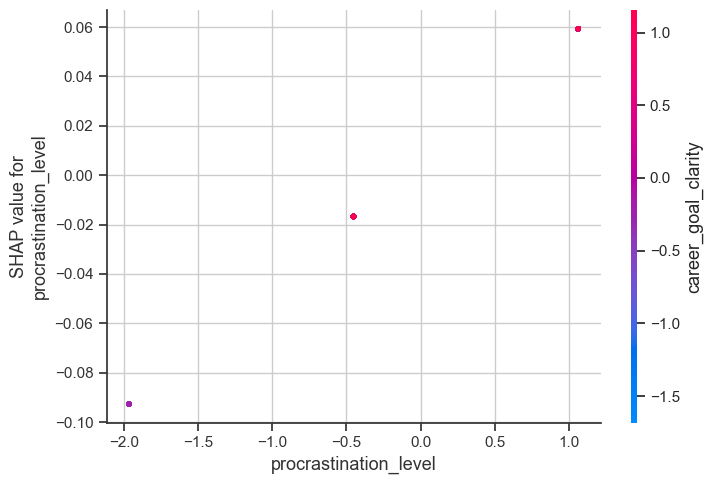

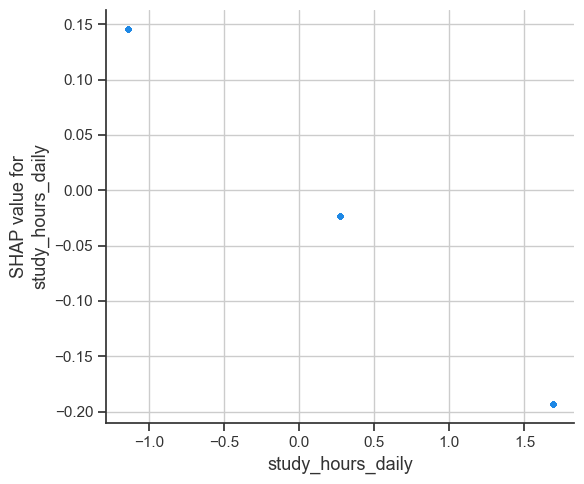

In [3]:
explainer.plot_dependence(
    "procrastination_level", data["X_test"], interaction="career_goal_clarity",
    save_path=config.PLOTS_DIR / "shap_dependence_procrastination.png",
)
plt.show()
explainer.plot_dependence(
    "study_hours_daily", data["X_test"],
    save_path=config.PLOTS_DIR / "shap_dependence_studyhours.png",
)
plt.show()

## Local explanations: one student per risk level

Interactive force plots saved as HTML, one each for an actual Low, Moderate, and
High Risk student, so a single prediction can be traced feature by feature.

In [4]:
y_reset = data["y_test"].reset_index(drop=True)
sample_rows = {}
for level, name in [(0, "low"), (1, "moderate"), (2, "high")]:
    position = int(y_reset.eq(level).idxmax())
    label_index = data["X_test"].index[position]
    sample_rows[name] = (position, label_index)
    explainer.force_plot_html(
        data["X_test"], position, config.PLOTS_DIR / f"shap_force_{name}.html"
    )
    print(f"{name:9s} risk student -> row index {label_index}")

low       risk student -> row index 1111
moderate  risk student -> row index 512
high      risk student -> row index 488


## LIME on the same model

LIME fits a local linear surrogate around one instance. Running it on the High
Risk student gives an independent read on which features drive that single
prediction.

In [5]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    data["X_train"].values,
    feature_names=feature_names,
    class_names=["Not High Risk", "High Risk"],
    mode="classification",
    random_state=config.RANDOM_SEED,
)


def predict_fn(array):
    return classifier.predict_proba(pd.DataFrame(array, columns=feature_names))


high_position = sample_rows["high"][0]
lime_exp = lime_explainer.explain_instance(
    data["X_test"].values[high_position], predict_fn, num_features=10
)
lime_exp.save_to_file(str(config.PLOTS_DIR / "lime_explanation_sample.html"))
lime_exp.as_list()

[('stress_level <= -0.98', -0.457743762960487),
 ('cgpa_category <= -0.43', 0.3509137128001904),
 ('study_consistency <= -0.11', 0.2636390905201006),
 ('attendance_percentage <= -0.97', 0.25800771778668713),
 ('year_class_Second Year (PG) <= 0.00', -0.052667344970640344),
 ('program_stream_BSc Cyber Security <= 0.00', 0.04000597660049241),
 ('career_interest_Other <= 0.00', -0.035009315124232825),
 ('year_class_First Year (PG) <= 0.00', -0.024855578233871335),
 ('strongest_asset_Management/Execution (Planning, Organizing, Discipline) <= 0.00',
  -0.024347171957195768),
 ('internal_barrier_Poor Time Management / Over-scheduling <= 0.00',
  -0.023271803086629374)]

## SHAP versus LIME

Compare the two methods on the same High Risk student: how many of the top
features they agree on.

In [6]:
import numpy as np

shap_row = explainer.shap_values(data["X_test"])[high_position]
shap_top = (
    pd.Series(np.abs(shap_row), index=feature_names).sort_values(ascending=False).head(8).index.tolist()
)


def lime_feature(condition):
    matches = [name for name in feature_names if name in condition]
    return max(matches, key=len) if matches else condition


lime_top = [lime_feature(cond) for cond, _ in lime_exp.as_list()][:8]
overlap = [f for f in shap_top if f in lime_top]

print("SHAP top 8:", shap_top)
print("LIME top 8:", lime_top)
print(f"\nAgreement: {len(overlap)}/8 -> {overlap}")

SHAP top 8: ['attendance_percentage', 'stress_level', 'study_consistency', 'cgpa_category', 'revision_frequency', 'routine_rating', 'main_distractor_Social media', 'internal_barrier_Procrastination / Low Motivation']
LIME top 8: ['stress_level', 'cgpa_category', 'study_consistency', 'attendance_percentage', 'year_class_Second Year (PG)', 'program_stream_BSc Cyber Security', 'career_interest_Other', 'year_class_First Year (PG)']

Agreement: 4/8 -> ['attendance_percentage', 'stress_level', 'study_consistency', 'cgpa_category']


**Reading the comparison.** SHAP and LIME are built differently. SHAP is
grounded in Shapley values and, for this linear model, gives the exact
contribution of each feature both globally and per student. LIME makes no such
guarantee: it fits a small linear model to random perturbations around the one
point, so it is local-only and approximate, and its ranking can shift a little
between runs.

Where they line up, confidence goes up. The two methods agree on most of the top
features for this student (stress, CGPA band, study consistency, attendance),
which is the reassuring outcome: the drivers aren't an artefact of one method.
Where they differ tends to be lower down the list, on features with small
contributions that LIME's local fit and SHAP's exact values rank in a slightly
different order. For a linear model I trust SHAP as the primary account and use
LIME as a sanity check, and this sanity check passes.

## Intervention engine

For each of the three students, turn the per-student SHAP values into a ranked
plan. The engine only surfaces behaviours that are (a) currently in an
addressable bad state and (b) pushing the student toward High Risk, so a
low-risk student may get few or none. This is the difference between a
prediction and something a student can act on.

In [7]:
shap_all = explainer.shap_values(data["X_test"])
for name, (position, label_index) in sample_rows.items():
    student = raw.loc[label_index].to_dict()
    plan = get_interventions(student, shap_all[position], feature_names, top_n=3)
    print(f"=== {name.upper()} RISK student (row {label_index}) ===")
    if not plan:
        print("  no addressable risk drivers flagged")
    for item in plan:
        print(f"  #{item['priority']} {item['feature']} = {item['current_value']} "
              f"| shap {item['shap_impact']} | {item['expected_impact']}")
        print(f"     {item['recommendation']}")
    print()

=== LOW RISK student (row 1111) ===
  #1 projects_internships = Not currently, but intend to in the future | shap 0.1589 | medium
     Apply to three internships or start one portfolio project this month, targeting startups and labs alongside larger firms.

=== MODERATE RISK student (row 512) ===
  #1 stress_level = 4.0 | shap 3.5188 | high
     Add 20 minutes of daily physical activity and speak to a counsellor or trusted peer. Use short breathing resets before study.
  #2 projects_internships = Not currently, but intend to in the future | shap 0.1589 | medium
     Apply to three internships or start one portfolio project this month, targeting startups and labs alongside larger firms.
  #3 events_participation = Never participate in such events | shap 0.1491 | medium
     Register for one upcoming hackathon or department event this term, focused on learning rather than winning.

=== HIGH RISK student (row 488) ===
  #1 events_participation = Never participate in such events | shap 0.1

## Key takeaways

- SHAP on the deployed logistic model puts stress, CGPA band, study consistency
  and attendance at the top. Procrastination and career clarity matter too,
  while raw study hours is not the single biggest lever, which is a more
  interesting story than the obvious one.
- LIME agrees with SHAP on most of the top features for the sampled student, so
  the drivers hold up under two independent methods.
- The intervention engine ranks only the addressable, risk-increasing
  behaviours, which is what makes the output a plan rather than just a score.
  Non-actionable drivers like CGPA are shown in the SHAP view but never
  recommended as fixes.